# Phase 4: Evaluate Extractions Against Ground Truth

Self-contained notebook — no project imports required.  
CPU-only evaluation of cleaned extraction JSONL against a ground truth CSV or JSONL.

**Inputs:**
- `cleaned_extractions.jsonl` — output of Stage 3 (clean)
- Ground truth CSV (with image identifier column) or JSONL (per-type fields)

**Outputs:**
- `evaluation_results.jsonl` — per-image scores (F1, precision, recall, field breakdown)
- Rich summary table

**Dependencies:** `pandas`, `rich`, `python-Levenshtein` (optional, falls back to exact match)

In [2]:
# ============================================================
# Configuration — edit these paths to match your run
# ============================================================
from pathlib import Path

CLEANED_EXTRACTIONS = Path(
    "../evaluation_data/output/cleaned_extractions.jsonl"
)
GROUND_TRUTH = Path("../evaluation_data/bank/ground_truth_bank.csv")
OUTPUT_DIR = Path("../evaluation_data/output")

# Evaluation method: "order_aware_f1" (default, position matters) or "f1" (set-based)
EVALUATION_METHOD = "order_aware_f1"

# Optional: epoch seconds when the pipeline started (for wall-clock reporting)
WALL_CLOCK_START = None  # e.g. 1713800000.0

# Auto-detect ground truth format
JSONL_MODE = GROUND_TRUTH.suffix == ".jsonl"

# Sanity check
for label, p in [("Extractions", CLEANED_EXTRACTIONS), ("Ground truth", GROUND_TRUTH)]:
    print(f"{label:15s}: {p.resolve()}  [{'OK' if p.exists() else 'MISSING'}]")
print(
    f"{'GT format':15s}: {'JSONL (per-type fields)' if JSONL_MODE else 'CSV (field_definitions lookup)'}"
)

Extractions    : /home/jovyan/nfs_share/tod_2026/evaluation_data/output/cleaned_extractions.jsonl  [OK]
Ground truth   : /home/jovyan/nfs_share/tod_2026/evaluation_data/bank/ground_truth_bank.csv  [OK]
GT format      : CSV (field_definitions lookup)


In [3]:
# ============================================================
# Field definitions (embedded from config/field_definitions.yaml)
# ============================================================
#
# Maps document type -> list of fields to evaluate.
# Validation-only fields (TRANSACTION_AMOUNTS_RECEIVED, ACCOUNT_BALANCE)
# are excluded from scoring.
#
# In JSONL mode, these are only used as fallback — each GT record
# carries exactly its type's fields.

DOC_TYPE_FIELDS: dict[str, list[str]] = {
    "invoice": [
        "DOCUMENT_TYPE",
        "BUSINESS_ABN",
        "SUPPLIER_NAME",
        "BUSINESS_ADDRESS",
        "PAYER_NAME",
        "PAYER_ADDRESS",
        "INVOICE_DATE",
        "LINE_ITEM_DESCRIPTIONS",
        "LINE_ITEM_QUANTITIES",
        "LINE_ITEM_PRICES",
        "LINE_ITEM_TOTAL_PRICES",
        "IS_GST_INCLUDED",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
    ],
    "receipt": [
        "DOCUMENT_TYPE",
        "BUSINESS_ABN",
        "SUPPLIER_NAME",
        "BUSINESS_ADDRESS",
        "PAYER_NAME",
        "PAYER_ADDRESS",
        "INVOICE_DATE",
        "LINE_ITEM_DESCRIPTIONS",
        "LINE_ITEM_QUANTITIES",
        "LINE_ITEM_PRICES",
        "LINE_ITEM_TOTAL_PRICES",
        "IS_GST_INCLUDED",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
    ],
    "bank_statement": [
        "DOCUMENT_TYPE",
        "STATEMENT_DATE_RANGE",
        "LINE_ITEM_DESCRIPTIONS",
        "TRANSACTION_DATES",
        "TRANSACTION_AMOUNTS_PAID",
    ],
    "travel": [
        "DOCUMENT_TYPE",
        "PASSENGER_NAME",
        "TRAVEL_MODE",
        "TRAVEL_ROUTE",
        "TRAVEL_DATES",
        "INVOICE_DATE",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
        "SUPPLIER_NAME",
    ],
    "logbook": [
        "DOCUMENT_TYPE",
        "VEHICLE_MAKE",
        "VEHICLE_MODEL",
        "VEHICLE_REGISTRATION",
        "ENGINE_CAPACITY",
        "LOGBOOK_PERIOD_START",
        "LOGBOOK_PERIOD_END",
        "ODOMETER_START",
        "ODOMETER_END",
        "TOTAL_KILOMETERS",
        "BUSINESS_KILOMETERS",
        "BUSINESS_USE_PERCENTAGE",
        "JOURNEY_DATES",
        "JOURNEY_DISTANCES",
        "JOURNEY_PURPOSES",
    ],
}

# Field type sets (drive type-aware matching in the scorer)
BOOLEAN_FIELDS = {"IS_GST_INCLUDED"}
TRANSACTION_LIST_FIELDS = {
    "TRANSACTION_DATES",
    "TRANSACTION_AMOUNTS_PAID",
    "TRANSACTION_AMOUNTS_RECEIVED",
    "ACCOUNT_BALANCE",
    "TRAVEL_DATES",
    "JOURNEY_DATES",
    "JOURNEY_DISTANCES",
}
VALIDATION_ONLY = {"TRANSACTION_AMOUNTS_RECEIVED", "ACCOUNT_BALANCE"}

# Document type equivalence for DOCUMENT_TYPE scoring
# (invoice == receipt for scoring purposes)
_EVAL_EQUIV = {
    "invoice": "invoice_receipt",
    "receipt": "invoice_receipt",
    "tax invoice": "invoice_receipt",
    "purchase receipt": "invoice_receipt",
    "bank_statement": "bank_statement",
    "statement": "bank_statement",
    "bank statement": "bank_statement",
    "travel": "travel",
    "travel_expense": "travel",
    "travel expense": "travel",
    "logbook": "logbook",
    "vehicle_logbook": "logbook",
    "vehicle logbook": "logbook",
}

print(
    f"Field definitions loaded: {', '.join(f'{k}({len(v)})' for k, v in DOC_TYPE_FIELDS.items())}"
)

Field definitions loaded: invoice(14), receipt(14), bank_statement(5), travel(9), logbook(15)


In [4]:
# ============================================================
# Evaluation engine (self-contained, no project imports)
# ============================================================
import json
import re
import time
from typing import Any

import pandas as pd

# ---------- I/O helpers ----------


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    """Read all records from a JSONL file."""
    records: list[dict[str, Any]] = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def write_jsonl(path: Path, records: list[dict[str, Any]]) -> int:
    """Write records to a JSONL file. Returns count."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        for record in records:
            f.write(json.dumps(record, default=str) + "\n")
    return len(records)


# ---------- Ground truth loading ----------

_GT_FILENAME_KEYS = ("filename", "image_name", "image_file", "file")


def load_ground_truth(gt_path: str | Path) -> dict[str, dict]:
    """Load ground truth from CSV or JSONL into {image_name: {field: value}} dict."""
    gt_path = Path(gt_path)

    if gt_path.suffix == ".jsonl":
        return _load_ground_truth_jsonl(gt_path)
    return _load_ground_truth_csv(gt_path)


def _load_ground_truth_jsonl(path: Path) -> dict[str, dict]:
    """Load JSONL ground truth. Each record carries only its type's fields."""
    gt_map: dict[str, dict] = {}
    records = read_jsonl(path)
    for record in records:
        # Find filename key
        name = None
        for key in _GT_FILENAME_KEYS:
            if key in record:
                name = record[key]
                break
        if not name:
            continue
        gt_map[str(name)] = record
    print(f"Ground truth (JSONL): {len(gt_map)} images from {path.name}")
    return gt_map


def _load_ground_truth_csv(path: Path) -> dict[str, dict]:
    """Load CSV ground truth."""
    df = pd.read_csv(path, dtype=str)
    print(f"Ground truth (CSV): {len(df)} rows, {len(df.columns)} columns")

    image_col = None
    for col in _GT_FILENAME_KEYS:
        if col in df.columns:
            image_col = col
            break
    if image_col is None:
        raise ValueError(
            f"No image identifier column found. Expected one of: {_GT_FILENAME_KEYS}"
        )

    gt_map = {}
    for _, row in df.iterrows():
        name = row[image_col]
        if pd.isna(name):
            continue
        gt_map[str(name)] = row.to_dict()
    print(f"Ground truth mapping: {len(gt_map)} images")
    return gt_map


# ---------- Date comparison helpers ----------

_MONTHS = {
    "jan": 1,
    "january": 1,
    "feb": 2,
    "february": 2,
    "mar": 3,
    "march": 3,
    "apr": 4,
    "april": 4,
    "may": 5,
    "jun": 6,
    "june": 6,
    "jul": 7,
    "july": 7,
    "aug": 8,
    "august": 8,
    "sep": 9,
    "sept": 9,
    "september": 9,
    "oct": 10,
    "october": 10,
    "nov": 11,
    "november": 11,
    "dec": 12,
    "december": 12,
}


def _parse_single_date(date_str: str) -> tuple[int, int, int] | None:
    """Parse a date string to (day, month, year)."""
    s = date_str.strip().lower()
    for dn in [
        "monday",
        "tuesday",
        "wednesday",
        "thursday",
        "friday",
        "saturday",
        "sunday",
        "mon",
        "tue",
        "wed",
        "thu",
        "fri",
        "sat",
        "sun",
    ]:
        if s.startswith(dn):
            s = s[len(dn) :].strip()
            break
    nums = re.findall(r"\d+", s)
    month_num = None
    for mn, mv in _MONTHS.items():
        if mn in s:
            month_num = mv
            break
    if not nums:
        return None
    if len(nums) >= 3:
        day, month, year = int(nums[0]), int(nums[1]), int(nums[2])
    elif len(nums) == 2 and month_num:
        day, month, year = int(nums[0]), month_num, int(nums[1])
    elif len(nums) == 2:
        day, month, year = int(nums[0]), int(nums[1]), 0
    else:
        return None
    if year < 100:
        year = 2000 + year if year <= 50 else 1900 + year
    return (day, month, year)


def _parse_date_range(text: str) -> list[tuple[int, int, int]]:
    """Parse date range -> list of (day, month, year)."""
    dates: list[tuple[int, int, int]] = []
    for sep in [" - ", " to ", " \u2013 ", " \u2014 ", "-"]:
        if sep in text.lower():
            parts = text.split(sep) if sep != "-" else re.split(r"\s*-\s*", text)
            parts = [p.strip() for p in parts if p.strip() and len(p.strip()) > 4]
            if len(parts) >= 2:
                for part in parts[:2]:
                    parsed = _parse_single_date(part)
                    if parsed:
                        dates.append(parsed)
                break
    if not dates:
        parsed = _parse_single_date(text)
        if parsed:
            dates.append(parsed)
    return dates


def _compare_date_field(extracted: str, ground_truth: str) -> float:
    """Semantic date comparison handling ranges and format variations."""
    ext_dates = _parse_date_range(extracted)
    gt_dates = _parse_date_range(ground_truth)
    if not ext_dates or not gt_dates:
        return 0.0
    if set(ext_dates) == set(gt_dates):
        return 1.0
    common = set(ext_dates) & set(gt_dates)
    if common:
        return len(common) / max(len(set(ext_dates)), len(set(gt_dates)))
    e_day, e_month, _ = ext_dates[0]
    g_day, g_month, _ = gt_dates[0]
    if e_day == g_day and e_month == g_month:
        return 0.8
    return 0.0


def _compare_dates_fuzzy(ext: str, gt: str) -> bool:
    """Fuzzy date comparison for transaction list items."""
    if ext.strip() == gt.strip():
        return True
    e = _parse_single_date(ext)
    g = _parse_single_date(gt)
    if e is None or g is None:
        return False
    matches = sum(1 for a, b in zip(e, g, strict=True) if a == b and a != 0)
    return matches >= 2


# ---------- Matching helpers ----------


def _parse_boolean(value: str) -> bool | None:
    v = str(value).lower().strip()
    if v in ("true", "1", "yes", "y"):
        return True
    if v in ("false", "0", "no", "n"):
        return False
    return None


def _fuzzy_text_match(t1: str, t2: str, threshold: float = 0.75) -> bool:
    w1, w2 = set(t1.lower().split()), set(t2.lower().split())
    if not w1 or not w2:
        return t1.lower().strip() == t2.lower().strip()
    return len(w1 & w2) / len(w1 | w2) >= threshold


def _transaction_item_matches(ext: str, gt: str, field_name: str) -> bool:
    """Type-aware matching for individual transaction list items."""
    if "AMOUNT" in field_name or "BALANCE" in field_name:
        try:
            e = float(re.sub(r"[^\d.-]", "", ext))
            g = float(re.sub(r"[^\d.-]", "", gt))
            tol = abs(g * 0.01) if g != 0 else 0.01
            return abs(e - g) <= tol
        except (ValueError, TypeError):
            return False
    if "DATE" in field_name:
        return _compare_dates_fuzzy(ext, gt)
    return ext.lower().strip() == gt.lower().strip()


# ---------- Order-aware F1 scorer (default) ----------


def calculate_field_f1(
    extracted_value: str,
    ground_truth_value: str,
    field_name: str,
) -> dict[str, Any]:
    """Position-aware F1 for a single field. Returns {f1_score, precision, recall, tp, fp, fn}."""
    extracted = str(extracted_value).strip() if extracted_value else "NOT_FOUND"
    ground_truth = (
        str(ground_truth_value).strip() if ground_truth_value else "NOT_FOUND"
    )

    def _result(f1: float, p: float, r: float, tp: int, fp: int, fn: int) -> dict:
        return {
            "f1_score": f1,
            "precision": p,
            "recall": r,
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

    # --- NOT_FOUND handling ---
    if ground_truth.upper() == "NOT_FOUND":
        ok = extracted.upper() == "NOT_FOUND"
        return _result(
            1.0 if ok else 0.0, 1.0 if ok else 0.0, 1.0, 0, 0 if ok else 1, 0
        )
    if extracted.upper() == "NOT_FOUND":
        gt_n = (
            len([i for i in ground_truth.split("|") if i.strip()])
            if "|" in ground_truth
            else 1
        )
        return _result(0.0, 0.0, 0.0, 0, 0, gt_n)

    # --- Single-value fields ---
    if "|" not in extracted and "|" not in ground_truth:
        # Transaction list single items
        if field_name in TRANSACTION_LIST_FIELDS:
            m = _transaction_item_matches(extracted, ground_truth, field_name)
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        en = " ".join(extracted.split())
        gn = " ".join(ground_truth.split())

        # Boolean
        if field_name in BOOLEAN_FIELDS:
            eb, gb = _parse_boolean(en), _parse_boolean(gn)
            m = eb is not None and gb is not None and eb == gb
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # DOCUMENT_TYPE equivalence
        if field_name == "DOCUMENT_TYPE":
            ec = _EVAL_EQUIV.get(en.lower(), en.lower())
            gc = _EVAL_EQUIV.get(gn.lower(), gn.lower())
            m = ec == gc
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # Date fields
        date_keywords = ["DATE", "DUE_DATE", "INVOICE_DATE", "STATEMENT_DATE"]
        if any(kw in field_name.upper() for kw in date_keywords):
            s = _compare_date_field(en, gn)
            return _result(
                s, s, s, 1 if s > 0 else 0, 0 if s > 0 else 1, 0 if s > 0 else 1
            )

        # Monetary single fields
        if field_name in ("GST_AMOUNT", "TOTAL_AMOUNT", "INVOICE_TOTAL", "SUBTOTAL"):
            try:
                e_num = float(re.sub(r"[^\d.-]", "", en))
                g_num = float(re.sub(r"[^\d.-]", "", gn))
                tol = abs(g_num * 0.01) if g_num != 0 else 0.01
                m = abs(e_num - g_num) <= tol
            except (ValueError, TypeError):
                m = False
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # ID fields (ABN, invoice numbers) — exact match
        id_keywords = ["ABN", "NUMBER", "ID", "REFERENCE", "BSB"]
        if any(kw in field_name.upper() for kw in id_keywords):
            label_pat = r"^(ABN|BSB|ACN|GST|TAX|ID|NUMBER|NO\.?|#)\s*:?\s*"
            ec = re.sub(r"[\s\-]", "", re.sub(label_pat, "", en, flags=re.IGNORECASE))
            gc = re.sub(r"[\s\-]", "", re.sub(label_pat, "", gn, flags=re.IGNORECASE))
            s = 1.0 if ec.lower() == gc.lower() else 0.0
        else:
            # Text fields — Levenshtein (ANLS-style) with fallback
            try:
                from Levenshtein import distance as lev_dist

                d = lev_dist(en.lower(), gn.lower())
                mx = max(len(en), len(gn))
                sim = 1.0 - (d / mx) if mx else 1.0
                s = sim if sim >= 0.5 else 0.0
            except ImportError:
                s = 1.0 if en.lower() == gn.lower() else 0.0

        return _result(
            s, s, s, 1 if s > 0.5 else 0, 0 if s > 0.5 else 1, 0 if s > 0.5 else 1
        )

    # --- List fields (pipe-separated) — position-aware ---
    ext_items = [i.strip() for i in extracted.split("|") if i.strip()]
    gt_items = [i.strip() for i in ground_truth.split("|") if i.strip()]

    tp = fp = fn = 0
    for i in range(max(len(ext_items), len(gt_items))):
        if i < len(gt_items) and i < len(ext_items):
            if field_name in TRANSACTION_LIST_FIELDS:
                match = _transaction_item_matches(ext_items[i], gt_items[i], field_name)
            else:
                match = _fuzzy_text_match(ext_items[i], gt_items[i], 0.75)
            if match:
                tp += 1
            else:
                fn += 1  # substitution error
        elif i < len(gt_items):
            fn += 1
        else:
            fp += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return _result(f1, precision, recall, tp, fp, fn)


# ---------- Simple evaluator (missing/incorrect field lists) ----------


def simple_evaluate(extracted: dict, ground_truth: dict) -> tuple[list[str], list[str]]:
    """Return (missing_fields, incorrect_fields) for reporting."""
    missing, incorrect = [], []
    for field in ground_truth:
        if field in VALIDATION_ONLY:
            continue
        gt_val = str(ground_truth.get(field, "")).strip()
        if not gt_val:
            continue
        ext_val = str(extracted.get(field, "")).strip()
        if not ext_val:
            missing.append(field)
        elif ext_val.lower() != gt_val.lower():
            incorrect.append(field)
    return missing, incorrect


print("Evaluation engine loaded.")

Evaluation engine loaded.


In [5]:
# ============================================================
# Run evaluation
# ============================================================
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("evaluate")

# 1. Read inputs
records = read_jsonl(CLEANED_EXTRACTIONS)
if not records:
    raise FileNotFoundError(f"No records in {CLEANED_EXTRACTIONS}")
log.info("Read %d cleaned extractions", len(records))

gt_map = load_ground_truth(GROUND_TRUTH)

# 2. Evaluate each record
eval_results: list[dict[str, Any]] = []

for record in records:
    image_name = record["image_name"]
    doc_type = record.get("document_type", "invoice")

    # Skip error records
    if record.get("error"):
        eval_results.append(
            {
                "image_name": image_name,
                "document_type": doc_type,
                "error": record["error"],
                "overall_accuracy": 0,
                "median_f1": 0,
            }
        )
        continue

    # Look up ground truth (exact match, then stem match)
    gt = gt_map.get(image_name, {})
    if not gt:
        stem = Path(image_name).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break
    if not gt:
        eval_results.append(
            {
                "image_name": image_name,
                "document_type": doc_type,
                "error": f"No ground truth for {image_name}",
                "overall_accuracy": 0,
                "median_f1": 0,
            }
        )
        continue

    extracted_data = record.get("extracted_data", {})

    # Filter ground truth to doc-type-specific fields.
    # JSONL mode: use the GT record's own keys (each record carries only its
    # type's fields) — no DOC_TYPE_FIELDS lookup needed.
    if JSONL_MODE:
        eval_fields = [k for k in gt if k not in _GT_FILENAME_KEYS]
    else:
        eval_fields = DOC_TYPE_FIELDS.get(
            doc_type.lower(), DOC_TYPE_FIELDS.get("invoice", [])
        )
    filtered_gt = {f: gt[f] for f in eval_fields if f in gt}

    # Simple eval for missing/incorrect lists
    missing_fields, incorrect_fields = simple_evaluate(extracted_data, filtered_gt)

    # F1 scoring per field
    field_scores: dict[str, dict] = {}
    total_f1 = total_p = total_r = 0.0

    for field in filtered_gt:
        ext_val = extracted_data.get(field, "NOT_FOUND")
        gt_val = filtered_gt.get(field, "NOT_FOUND")
        metrics = calculate_field_f1(ext_val, gt_val, field)
        field_scores[field] = metrics
        total_f1 += metrics["f1_score"]
        total_p += metrics["precision"]
        total_r += metrics["recall"]

    n = len(field_scores)
    overall_acc = total_f1 / n if n else 0.0
    overall_p = total_p / n if n else 0.0
    overall_r = total_r / n if n else 0.0

    # Median F1 (more robust than mean)
    f1_vals = sorted(s["f1_score"] for s in field_scores.values())
    if f1_vals:
        mid = len(f1_vals) // 2
        median_f1 = (
            (f1_vals[mid - 1] + f1_vals[mid]) / 2
            if len(f1_vals) % 2 == 0
            else f1_vals[mid]
        )
    else:
        median_f1 = 0.0

    eval_results.append(
        {
            "image_name": image_name,
            "document_type": doc_type,
            "overall_accuracy": overall_acc,
            "median_f1": median_f1,
            "overall_precision": overall_p,
            "overall_recall": overall_r,
            "total_fields": n,
            "correct_fields": sum(
                1 for s in field_scores.values() if s["f1_score"] == 1.0
            ),
            "missing_fields": missing_fields,
            "incorrect_fields": incorrect_fields,
            "fields_extracted": len(
                [k for k, v in extracted_data.items() if v != "NOT_FOUND"]
            ),
            "field_scores": field_scores,
            "overall_metrics": {
                "overall_accuracy": overall_acc,
                "median_f1": median_f1,
                "overall_precision": overall_p,
                "overall_recall": overall_r,
                "meets_threshold": median_f1 >= 0.8,
            },
        }
    )

# 3. Write output
output_path = OUTPUT_DIR / "evaluation_results.jsonl"
count = write_jsonl(output_path, eval_results)
log.info("Wrote %d evaluation results to %s", count, output_path)

# 4. Summary stats
scored = [r for r in eval_results if "median_f1" in r and not r.get("error")]
if scored:
    avg_median = sum(r["median_f1"] for r in scored) / len(scored)
    avg_mean = sum(r["overall_accuracy"] for r in scored) / len(scored)
    log.info(
        "Summary: %d images, avg F1 (median)=%.3f, avg F1 (mean)=%.3f",
        len(scored),
        avg_median,
        avg_mean,
    )
else:
    log.warning("No images scored -- check ground truth alignment")

INFO: Read 15 cleaned extractions
INFO: Wrote 15 evaluation results to ../../evaluation_data/output/evaluation_results.jsonl
INFO: Summary: 15 images, avg F1 (median)=0.881, avg F1 (mean)=0.821


Ground truth (CSV): 15 rows, 20 columns
Ground truth mapping: 15 images


In [6]:
# ============================================================
# Execution Summary (Rich table)
# ============================================================
from rich.console import Console
from rich.table import Table

console = Console()
num = len(eval_results)
total_inference = sum(r.get("processing_time", 0.0) for r in records)

wall_s = (time.time() - WALL_CLOCK_START) if WALL_CLOCK_START else None
denom = wall_s if (wall_s and wall_s > 0) else total_inference
throughput = (num / denom * 60.0) if denom > 0 else 0.0

scored = [r for r in eval_results if "median_f1" in r and not r.get("error")]
avg_mean = (
    sum(r.get("overall_accuracy", 0) for r in scored) / len(scored) if scored else 0.0
)
avg_median = sum(r.get("median_f1", 0) for r in scored) / len(scored) if scored else 0.0

table = Table(title="Execution Summary", show_header=True, header_style="bold")
table.add_column("Metric", style="cyan")
table.add_column("Value", style="green")
table.add_row("Images Processed", str(num))
if wall_s is not None:
    table.add_row("Wall Clock Time", f"{wall_s:.1f}s")
table.add_row("Inference Time", f"{total_inference:.1f}s")
table.add_row("Throughput", f"{throughput:.2f} images/min")
if scored:
    table.add_row("Avg F1 (mean)", f"{avg_mean:.3f}")
    table.add_row("Avg F1 (median)", f"{avg_median:.3f}")
table.add_row("Output Directory", str(OUTPUT_DIR))

console.print()
console.print(table)

# Document type breakdown
doc_types: dict[str, int] = {}
for r in eval_results:
    dt = r.get("document_type", "UNKNOWN")
    doc_types[dt] = doc_types.get(dt, 0) + 1
if doc_types:
    console.print("\n[bold]Document Types:[/bold]")
    for dt, c in sorted(doc_types.items()):
        console.print(f"  {dt}: {c}")

                 Execution Summary                 
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric           ┃ Value                        ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Images Processed │ 15                           │
│ Inference Time   │ 1769.2s                      │
│ Throughput       │ 0.51 images/min              │
│ Avg F1 (mean)    │ 0.821                        │
│ Avg F1 (median)  │ 0.881                        │
│ Output Directory │ ../../evaluation_data/output │
└──────────────────┴──────────────────────────────┘

Document Types:

BANK_STATEMENT: 15

In [7]:
# ============================================================
# Per-image results
# ============================================================
for r in eval_results:
    f1 = r.get("median_f1", "N/A")
    acc = r.get("overall_accuracy", "N/A")
    err = r.get("error", "")
    tag = f"  ERROR: {err}" if err else ""
    f1_str = f"{f1:.3f}" if isinstance(f1, float) else str(f1)
    acc_str = f"{acc:.3f}" if isinstance(acc, float) else str(acc)
    print(f"{r['image_name']:40s}  median_f1={f1_str:8s}  accuracy={acc_str}{tag}")

cba_amount_balance.png                    median_f1=1.000     accuracy=0.880
cba_date_grouped.png                      median_f1=0.889     accuracy=0.806
cba_date_grouped_cont.png                 median_f1=1.000     accuracy=0.993
cba_debit_credit.png                      median_f1=1.000     accuracy=0.778
cba_highligted.png                        median_f1=1.000     accuracy=0.800
cba_home_loan.png                         median_f1=0.857     accuracy=0.571
image_003.png                             median_f1=1.000     accuracy=1.000
image_009.png                             median_f1=0.750     accuracy=0.550
low_contrast.png                          median_f1=1.000     accuracy=0.994
nab_classic_highligted.png                median_f1=1.000     accuracy=0.982
synthetic_chrono.png                      median_f1=1.000     accuracy=0.984
synthetic_multiline.png                   median_f1=1.000     accuracy=0.978
synthetic_reverse_chrono.png              median_f1=0.200     accuracy=0.482

In [8]:
# ============================================================
# Misclassified Images — predicted vs ground truth DOCUMENT_TYPE
# ============================================================
from rich.table import Table as RichTable

misclassified: list[dict[str, str]] = []

for r in eval_results:
    if r.get("error"):
        continue
    fs = r.get("field_scores", {})
    dt_score = fs.get("DOCUMENT_TYPE", {})
    if dt_score and dt_score.get("f1_score", 1.0) < 1.0:
        # Look up predicted and ground truth values
        rec = next((x for x in records if x["image_name"] == r["image_name"]), {})
        extracted_data = rec.get("extracted_data", {})
        predicted = extracted_data.get("DOCUMENT_TYPE", r.get("document_type", "?"))

        gt = gt_map.get(r["image_name"], {})
        if not gt:
            stem = Path(r["image_name"]).stem
            for k in gt_map:
                if Path(k).stem == stem or k == stem:
                    gt = gt_map[k]
                    break
        gt_type = gt.get("DOCUMENT_TYPE", "?")

        misclassified.append(
            {
                "image": r["image_name"],
                "predicted": predicted,
                "ground_truth": gt_type,
            }
        )

if misclassified:
    t = RichTable(
        title=f"Misclassified Images ({len(misclassified)})",
        show_header=True,
        header_style="bold red",
    )
    t.add_column("Image", style="cyan")
    t.add_column("Predicted", style="yellow")
    t.add_column("Ground Truth", style="green")
    for m in misclassified:
        t.add_row(m["image"], m["predicted"], m["ground_truth"])
    console.print()
    console.print(t)
else:
    console.print(
        "\n[bold green]All images correctly classified![/bold green] "
        f"({len([r for r in eval_results if not r.get('error')])} images)"
    )

All images correctly classified! (15 images)

In [9]:
# ============================================================
# Field-level breakdown for a single image
# ============================================================
scored = [r for r in eval_results if "field_scores" in r]
if scored:
    sample = scored[0]  # Change index or filter by name
    print(f"Image: {sample['image_name']}  (type: {sample['document_type']})")
    print(
        f"Overall: median_f1={sample['median_f1']:.3f}, accuracy={sample['overall_accuracy']:.3f}"
    )
    print()
    for field, s in sample["field_scores"].items():
        print(
            f"  {field:35s}  F1={s['f1_score']:.3f}  P={s['precision']:.3f}  R={s['recall']:.3f}"
        )
else:
    print("No scored results found.")

Image: cba_amount_balance.png  (type: BANK_STATEMENT)
Overall: median_f1=1.000, accuracy=0.880

  DOCUMENT_TYPE                        F1=1.000  P=1.000  R=1.000
  STATEMENT_DATE_RANGE                 F1=1.000  P=1.000  R=1.000
  LINE_ITEM_DESCRIPTIONS               F1=0.400  P=1.000  R=0.250
  TRANSACTION_DATES                    F1=1.000  P=1.000  R=1.000
  TRANSACTION_AMOUNTS_PAID             F1=1.000  P=1.000  R=1.000


In [10]:
# ============================================================
# Visualization — build DataFrames from eval_results
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Per-image DataFrame
rows = []
for r in eval_results:
    if r.get("error"):
        continue
    # Find matching record for processing_time
    proc_time = 0.0
    for rec in records:
        if rec["image_name"] == r["image_name"]:
            proc_time = rec.get("processing_time", 0.0)
            break
    rows.append(
        {
            "image": Path(r["image_name"]).stem,
            "doc_type": r.get("document_type", "unknown"),
            "mean_f1": r["overall_accuracy"],
            "median_f1": r["median_f1"],
            "precision": r.get("overall_precision", 0.0),
            "recall": r.get("overall_recall", 0.0),
            "correct": r.get("correct_fields", 0),
            "total": r.get("total_fields", 0),
            "proc_time": proc_time,
        }
    )

df = pd.DataFrame(rows)

# Field-level DataFrame (rows=fields, cols=images)
all_fields: set[str] = set()
for r in eval_results:
    if "field_scores" in r:
        all_fields |= r["field_scores"].keys()

field_rows = []
for field in sorted(all_fields):
    row: dict[str, Any] = {"field": field}
    for r in eval_results:
        if "field_scores" not in r:
            continue
        stem = Path(r["image_name"]).stem
        row[stem] = r["field_scores"].get(field, {}).get("f1_score", np.nan)
    field_rows.append(row)

df_fields = pd.DataFrame(field_rows).set_index("field")

print(f"Dashboard data: {len(df)} images, {len(df_fields)} fields")
display(df[["image", "doc_type", "mean_f1", "median_f1", "precision", "recall"]])

Dashboard data: 15 images, 5 fields


,image,doc_type,mean_f1,median_f1,precision,recall
0,cba_amount_balance,BANK_STATEMENT,0.880000,1.000000,1.0,0.850000
1,cba_date_grouped,BANK_STATEMENT,0.806349,0.888889,1.0,0.720000
2,cba_date_grouped_cont,BANK_STATEMENT,0.993103,1.000000,1.0,0.986667
3,cba_debit_credit,BANK_STATEMENT,0.777778,1.000000,0.8,0.760000
4,cba_highligted,BANK_STATEMENT,0.800000,1.000000,0.8,0.800000
5,cba_home_loan,BANK_STATEMENT,0.571429,0.857143,0.6,0.550000
6,image_003,BANK_STATEMENT,1.000000,1.000000,1.0,1.000000
7,image_009,BANK_STATEMENT,0.550000,0.750000,0.6,0.520000
8,low_contrast,BANK_STATEMENT,0.993548,1.000000,1.0,0.987500
9,nab_classic_highligted,BANK_STATEMENT,0.981818,1.000000,1.0,0.966667


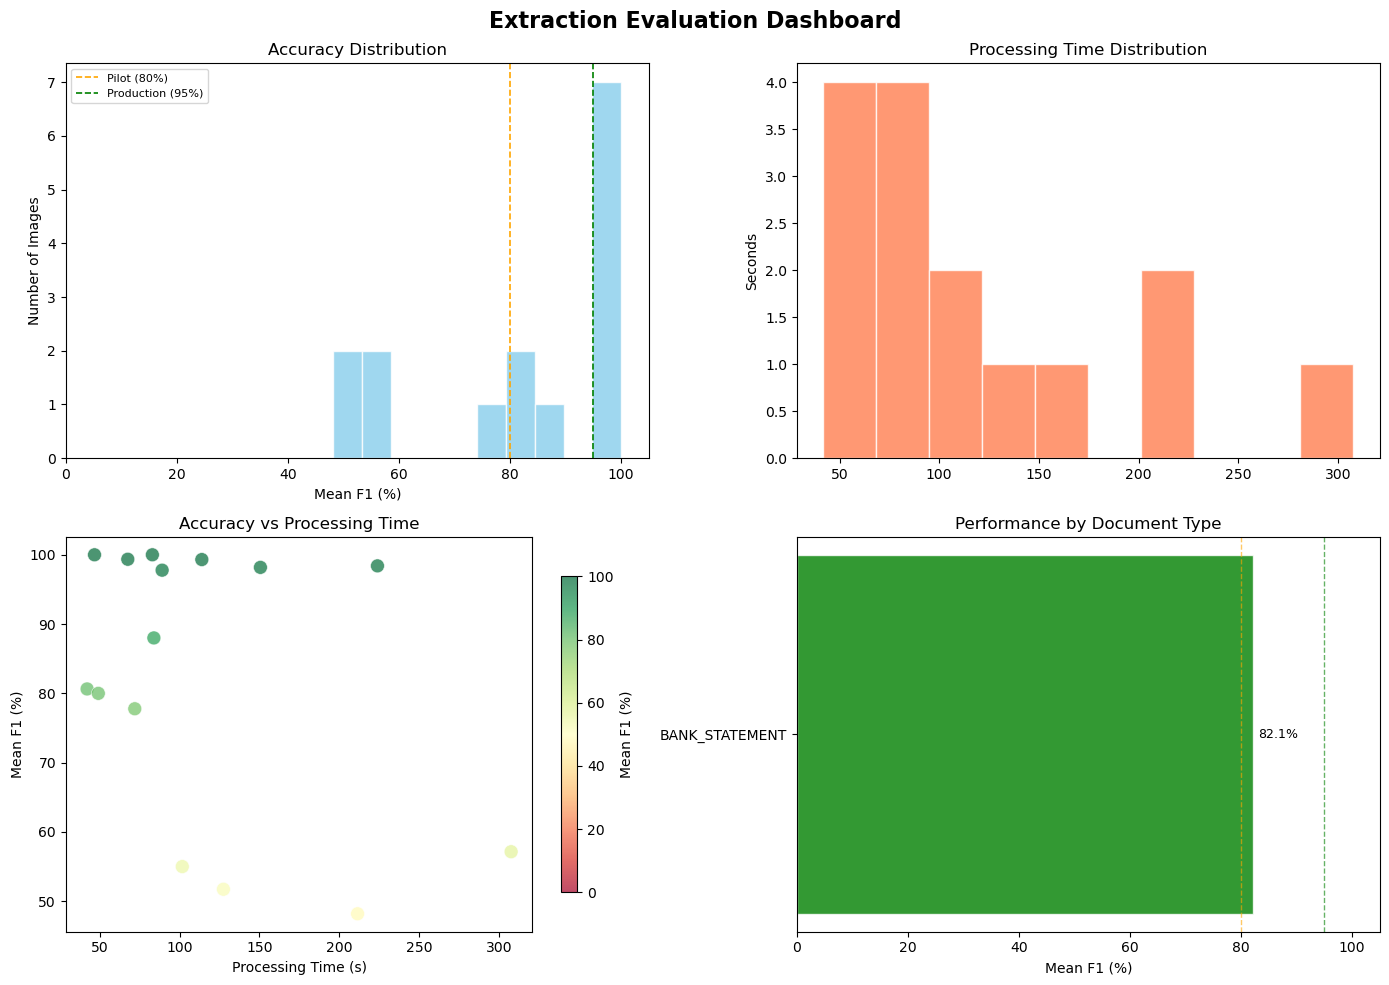

In [11]:
# ============================================================
# 2x2 Performance Dashboard
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Extraction Evaluation Dashboard", fontsize=16, fontweight="bold", y=0.98)

# --- Panel 1: Accuracy distribution histogram ---
ax = axes[0, 0]
accuracies = df["mean_f1"].to_numpy() * 100
if len(set(accuracies)) > 1:
    ax.hist(accuracies, bins=10, color="skyblue", edgecolor="white", alpha=0.8)
else:
    ax.bar(["All images"], [len(accuracies)], color="skyblue", edgecolor="white")
    ax.set_ylabel("Count")
ax.axvline(80, color="orange", linestyle="--", linewidth=1.2, label="Pilot (80%)")
ax.axvline(95, color="green", linestyle="--", linewidth=1.2, label="Production (95%)")
ax.set_xlabel("Mean F1 (%)")
ax.set_ylabel("Number of Images")
ax.set_title("Accuracy Distribution")
ax.set_xlim(0, 105)
ax.legend(fontsize=8)

# --- Panel 2: Processing time distribution ---
ax = axes[0, 1]
times = df["proc_time"].to_numpy()
if times.sum() > 0:
    doc_types_unique = df["doc_type"].unique()
    if len(doc_types_unique) > 1:
        data_by_type = [
            df.loc[df["doc_type"] == dt, "proc_time"].to_numpy()
            for dt in doc_types_unique
        ]
        bp = ax.boxplot(data_by_type, labels=doc_types_unique, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("coral")
            patch.set_alpha(0.7)
    else:
        ax.hist(times, bins=10, color="coral", edgecolor="white", alpha=0.8)
    ax.set_ylabel("Seconds")
    ax.set_title("Processing Time Distribution")
else:
    ax.text(
        0.5,
        0.5,
        "No timing data",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=12,
        color="grey",
    )
    ax.set_title("Processing Time Distribution")

# --- Panel 3: Accuracy vs Processing Time ---
ax = axes[1, 0]
if times.sum() > 0:
    scatter = ax.scatter(
        times,
        accuracies,
        c=accuracies,
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        s=100,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )
    plt.colorbar(scatter, ax=ax, label="Mean F1 (%)", shrink=0.8)
    ax.set_xlabel("Processing Time (s)")
    ax.set_ylabel("Mean F1 (%)")
else:
    ax.barh(df["image"], accuracies, color="skyblue", edgecolor="white")
    ax.set_xlabel("Mean F1 (%)")
    ax.axvline(80, color="orange", linestyle="--", linewidth=1)
    ax.axvline(95, color="green", linestyle="--", linewidth=1)
ax.set_title("Accuracy vs Processing Time")

# --- Panel 4: Document type performance ---
ax = axes[1, 1]
dtype_perf = df.groupby("doc_type")["mean_f1"].mean() * 100
colors = [
    "red" if v < 60 else "orange" if v < 80 else "green" for v in dtype_perf.to_numpy()
]
bars = ax.barh(
    dtype_perf.index,
    dtype_perf.to_numpy(),
    color=colors,
    edgecolor="white",
    alpha=0.8,
)
for bar, val in zip(bars, dtype_perf.to_numpy(), strict=False):
    ax.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
ax.axvline(80, color="orange", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(95, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Mean F1 (%)")
ax.set_xlim(0, 105)
ax.set_title("Performance by Document Type")

plt.tight_layout()
plt.show()

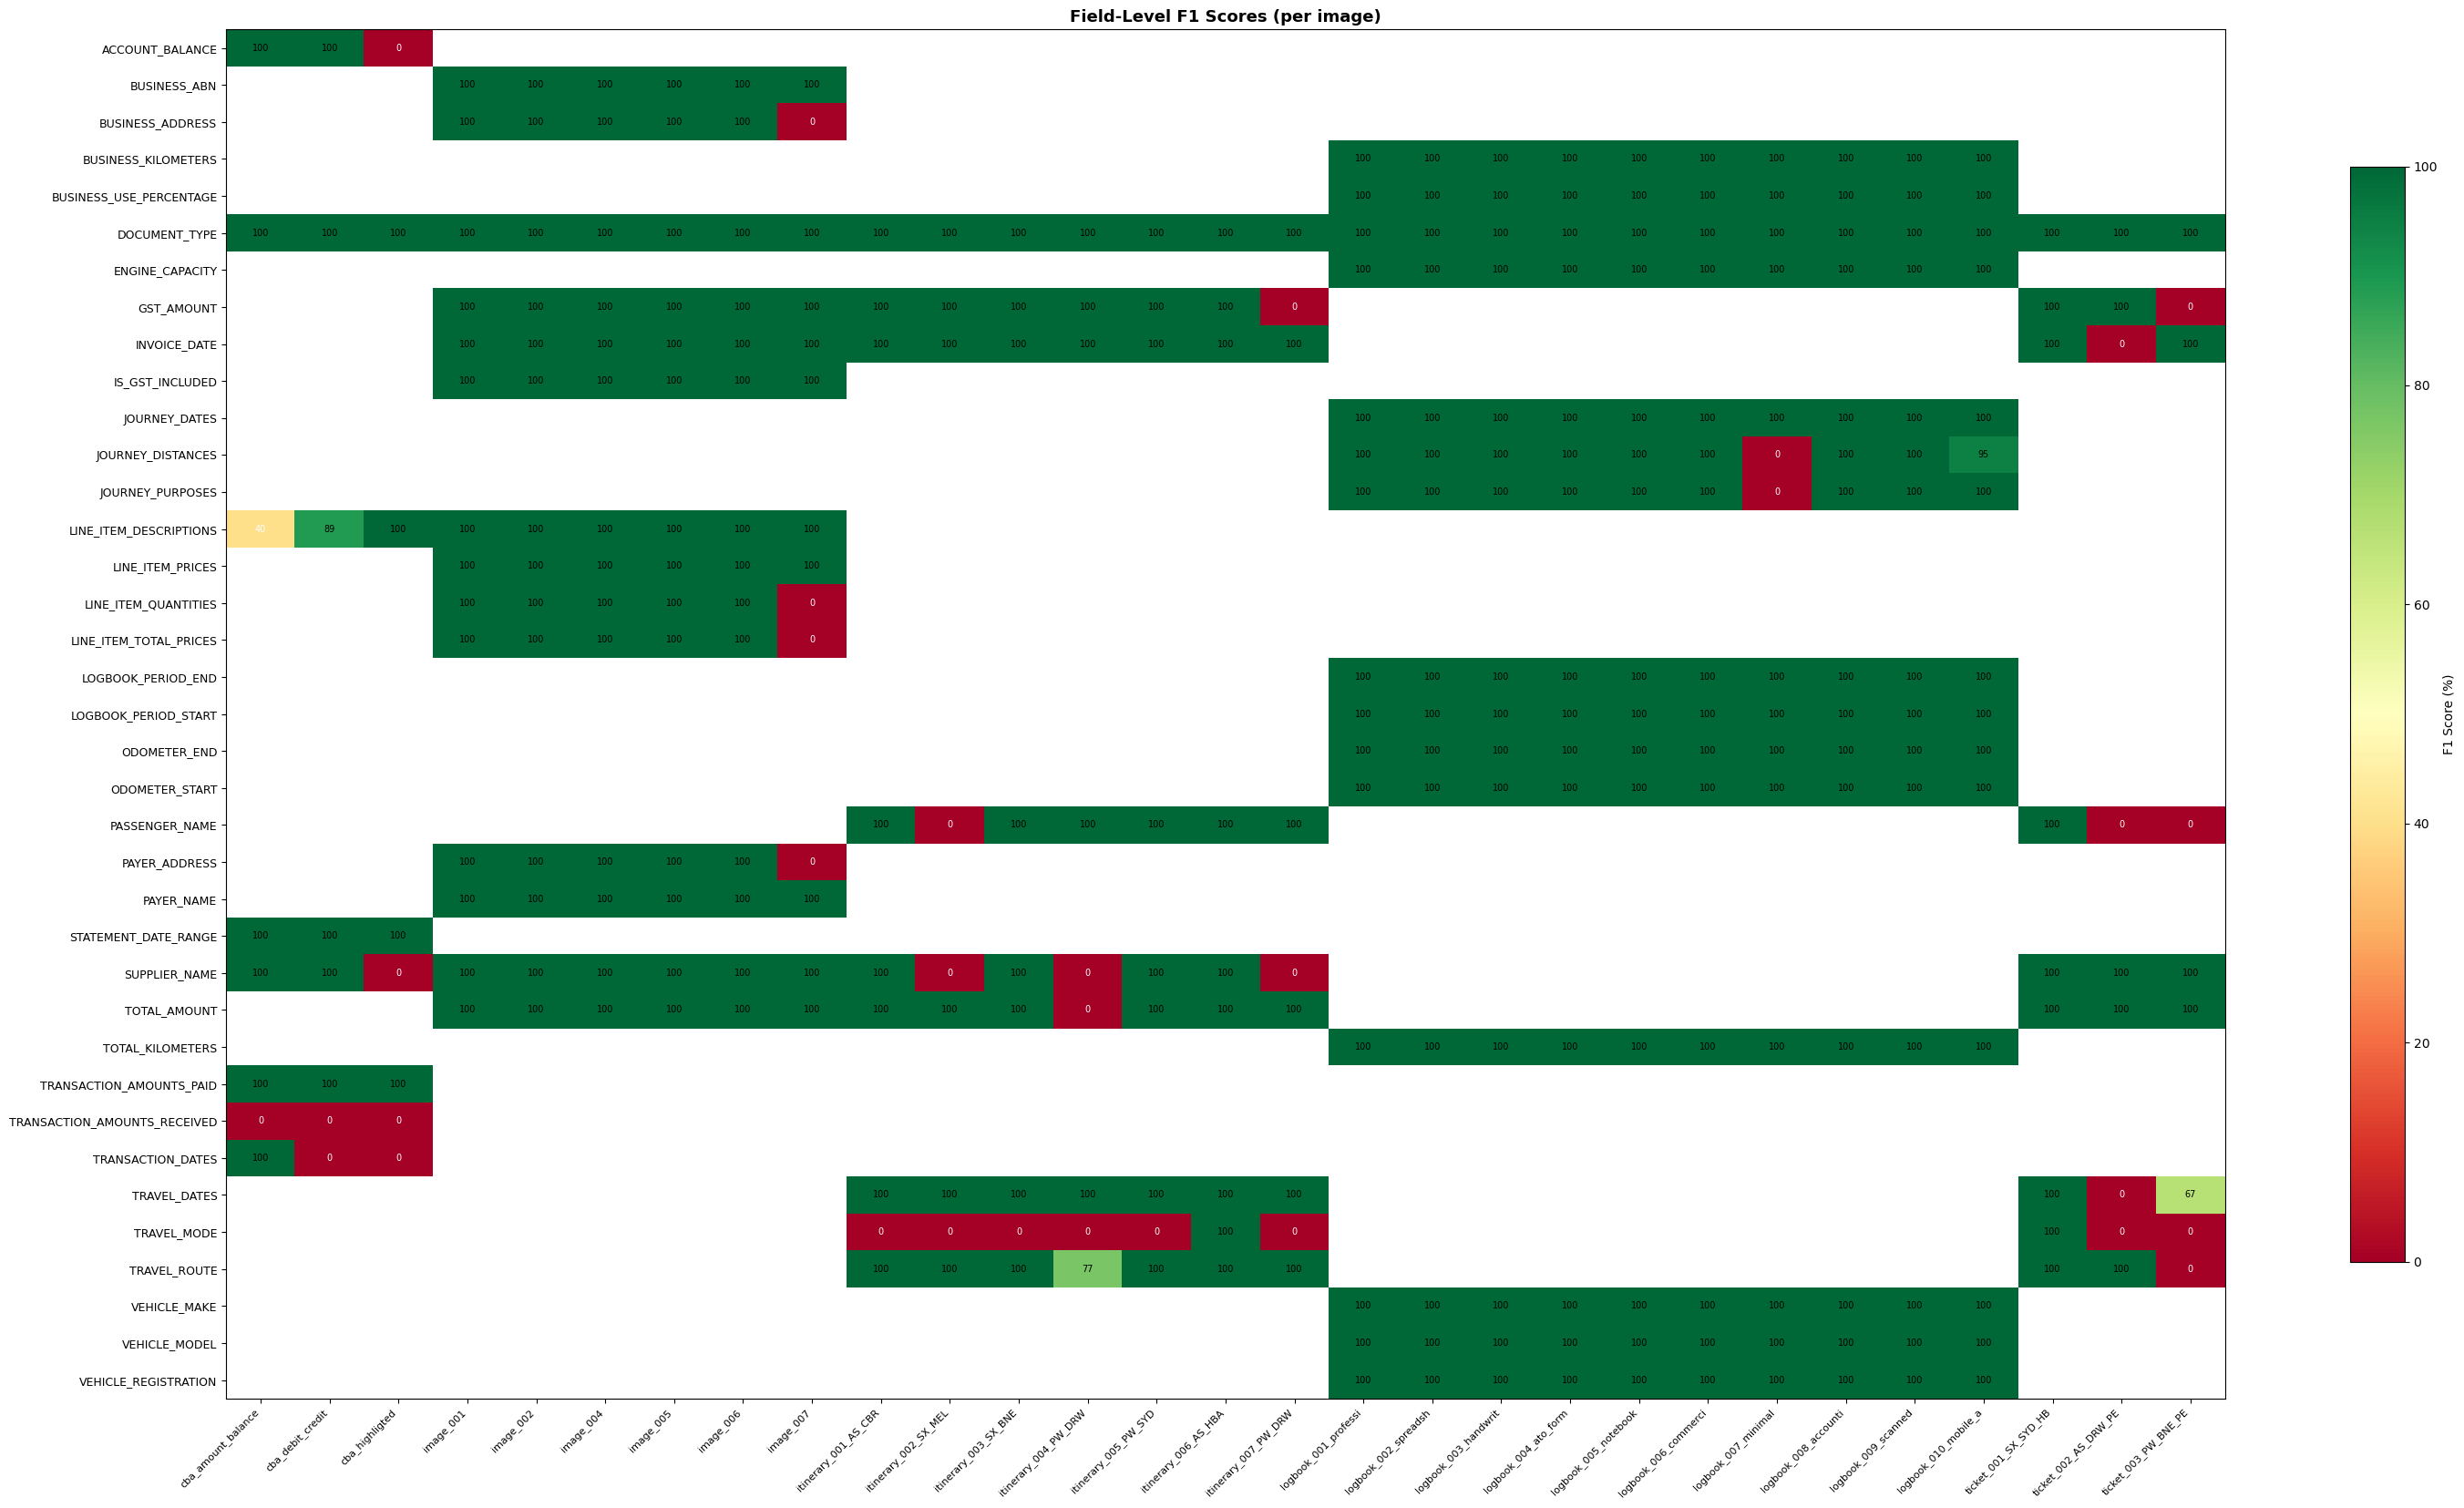


Field Summary Statistics:


,Avg F1 (%),Min F1 (%),Max F1 (%),Std (%)
field,,,,
LOGBOOK_PERIOD_START,100.0,100.0,100.0,0.0
LINE_ITEM_PRICES,100.0,100.0,100.0,0.0
VEHICLE_MODEL,100.0,100.0,100.0,0.0
VEHICLE_MAKE,100.0,100.0,100.0,0.0
TRANSACTION_AMOUNTS_PAID,100.0,100.0,100.0,0.0
TOTAL_KILOMETERS,100.0,100.0,100.0,0.0
STATEMENT_DATE_RANGE,100.0,100.0,100.0,0.0
PAYER_NAME,100.0,100.0,100.0,0.0
ODOMETER_START,100.0,100.0,100.0,0.0


In [10]:
# ============================================================
# Field-Level Accuracy Heatmap
# ============================================================
if not df_fields.empty:
    # Truncate long image names for readability
    short_cols = [c[:20] for c in df_fields.columns]

    fig_h = max(4, len(df_fields) * 0.45)
    fig_w = max(8, len(df_fields.columns) * 0.9 + 4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    data = df_fields.to_numpy() * 100  # convert to percentage
    im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(range(len(short_cols)))
    ax.set_xticklabels(short_cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(df_fields.index)))
    ax.set_yticklabels(df_fields.index, fontsize=9)

    # Annotate cells with F1 values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                continue
            color = "white" if val < 50 else "black"
            ax.text(
                j,
                i,
                f"{val:.0f}",
                ha="center",
                va="center",
                fontsize=7,
                color=color,
            )

    plt.colorbar(im, ax=ax, label="F1 Score (%)", shrink=0.8)
    ax.set_title("Field-Level F1 Scores (per image)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Field summary statistics
    summary = (
        pd.DataFrame(
            {
                "Avg F1 (%)": df_fields.mean(axis=1) * 100,
                "Min F1 (%)": df_fields.min(axis=1) * 100,
                "Max F1 (%)": df_fields.max(axis=1) * 100,
                "Std (%)": df_fields.std(axis=1) * 100,
            }
        )
        .round(1)
        .sort_values("Avg F1 (%)", ascending=False)
    )

    print("\nField Summary Statistics:")
    display(summary)
else:
    print("No field-level data to visualize.")

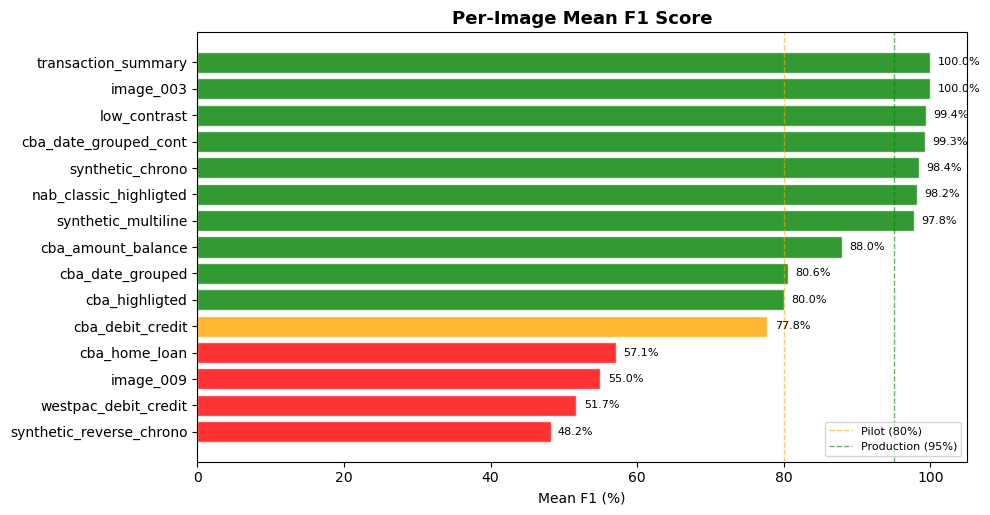

In [12]:
# ============================================================
# Per-Image F1 Scores (ranked bar chart)
# ============================================================
if not df.empty:
    df_sorted = df.sort_values("mean_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_sorted) * 0.35)))

    colors = [
        "red" if v < 0.6 else "orange" if v < 0.8 else "green"
        for v in df_sorted["mean_f1"]
    ]
    bars = ax.barh(
        df_sorted["image"],
        df_sorted["mean_f1"] * 100,
        color=colors,
        edgecolor="white",
        alpha=0.8,
    )

    for bar, val in zip(bars, df_sorted["mean_f1"] * 100, strict=False):
        ax.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=8,
        )

    ax.axvline(
        80,
        color="orange",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Pilot (80%)",
    )
    ax.axvline(
        95,
        color="green",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Production (95%)",
    )
    ax.set_xlabel("Mean F1 (%)")
    ax.set_xlim(0, 105)
    ax.set_title("Per-Image Mean F1 Score", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()